## Phase 6a - BioBERT Transformer

This section presents the implementation of a transformer-based model for drug–drug interaction (DDI) classification using BioBERT. Unlike classical machine learning approaches that rely on manually engineered features, BioBERT leverages contextual embeddings pre-trained on large-scale biomedical corpora, enabling deeper semantic understanding of clinical text.

The model is fine-tuned on the SemEval-2013 DDI dataset using a supervised learning setup. To ensure robust evaluation, a group-based train–validation split is applied to prevent sentence-level leakage, and class imbalance is addressed through weighted cross-entropy loss.

Macro F1 is used as the primary evaluation metric, as it assigns equal importance to all interaction types, including minority classes such as *int*, which are typically harder to predict. Additional metrics such as balanced accuracy, Matthews Correlation Coefficient (MCC), and Cohen’s kappa are also reported to provide a comprehensive performance assessment.

The objective of this section is to evaluate whether transformer-based models outperform classical approaches and to establish a strong benchmark for subsequent comparisons with other biomedical language models.

## Environment and Model Setup

This section initialises the BioBERT training environment by importing required libraries, loading project configuration settings, and setting the computation device. Random seeds are fixed to ensure reproducibility across runs.

Model configuration, training parameters, output paths, and plotting style are also defined here. This provides a consistent and reproducible setup for transformer-based training and evaluation.

In [ ]:
# Path Setup for Config Import
import sys, os
sys.path.insert(0, os.path.abspath('../'))
from config import *


# Standard Library Imports
import json
import warnings
import random
from pathlib import Path


# Data Handling and Numerical Libraries
import numpy as np
import pandas as pd


# Visualization Libraries
import matplotlib.pyplot as plt
import seaborn as sns


# Deep Learning Libraries
import torch
import torch.nn as nn
from torch.utils.data import Dataset


# Transformers
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    TrainingArguments,
    Trainer,
    EarlyStoppingCallback,
    EvalPrediction,
)


# ML Utilities
from sklearn.model_selection import GroupShuffleSplit
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    f1_score,
    balanced_accuracy_score,
    matthews_corrcoef,
    cohen_kappa_score,
)


# Configuration Setup
warnings.filterwarnings('ignore')


# Reproducibility
random.seed(RANDOM_STATE)
np.random.seed(RANDOM_STATE)
torch.manual_seed(RANDOM_STATE)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(RANDOM_STATE)


# Device Selection
DEVICE = torch.device(
    'cuda' if torch.cuda.is_available() else
    'mps' if torch.backends.mps.is_available() else
    'cpu'
)

if DEVICE.type == 'cuda':
    print(f'GPU : {torch.cuda.get_device_name(0)}')
    print(f'VRAM : {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB')
elif DEVICE.type == 'cpu':
    print('WARNING: CPU-only. ~2 hrs expected. Google Colab T4 is recommended.')


# Model Configuration
MODEL_NAME = 'BioBERT'
MODEL_ID = BIOBERT_MODEL_ID
CASED = True


# Output Directories
OUTPUT_DIR = BIOBERT_DIR
FIG_DIR = Path(str(PLOTS_BIOBERT_DIR))
FIG_DIR.mkdir(parents=True, exist_ok=True)


# Training Parameters
MAX_LEN = TRANSFORMER_MAX_LEN
BATCH_SIZE = TRANSFORMER_BATCH_SIZE
EPOCHS = TRANSFORMER_EPOCHS
LR = TRANSFORMER_LR
WARMUP_RATIO = TRANSFORMER_WARMUP
WEIGHT_DECAY = TRANSFORMER_WD

TEXT_COL = 'sentence_masked' if USE_DRUG_MASKING else 'sentence_original'


# Plot Styling
plt.rcParams.update({
    'figure.facecolor': 'white',
    'axes.facecolor': 'white',
    'axes.grid': True,
    'grid.alpha': 0.3,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'font.size': 11,
})


# Label Colours
LABEL_COLOURS = {
    'false': '#888780',
    'effect': '#378ADD',
    'mechanism': '#7F77DD',
    'advise': '#EF9F27',
    'int': '#D85A30',
}

for path in [TRAIN_PROCESSED, TEST_PROCESSED]:
    status = 'FOUND' if os.path.exists(path) else 'NOT FOUND'

/Users/carinadesouza/Documents/Projects/Python/Drug Drug Interaction NLP project/.venv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Model : BioBERT (dmis-lab/biobert-base-cased-v1.2)
MAX_LEN=128  BATCH_SIZE=16  EPOCHS=4  LR=2e-05
TEXT_COL: sentence_masked



## Data Loading and Train–Validation Split

This section loads the processed training and test datasets and prepares them for transformer-based modelling. Labels are mapped to numerical values to enable model training.

A group-based split is applied using sentence identifiers to prevent data leakage between training and validation sets, ensuring reliable evaluation.

In [2]:
# Load Data
print('Loading data')

train_df = pd.read_csv(TRAIN_PROCESSED)
test_df = pd.read_csv(TEST_PROCESSED)

print(f'Train: {len(train_df):,} rows | Test: {len(test_df):,} rows')


# Column Checks
for col in [TEXT_COL, 'interaction_type', 'sentence_id']:
    assert col in train_df.columns, f'Missing column: {col} — run Phase 3 first'


# Label Mapping
train_df['label'] = train_df['interaction_type'].map(LABEL2ID)
test_df['label'] = test_df['interaction_type'].map(LABEL2ID)

assert train_df['label'].isna().sum() == 0, 'Unmapped labels'


# Train–Validation Split (Group-based)
gss = GroupShuffleSplit(
    n_splits=1,
    test_size=0.1,
    random_state=RANDOM_STATE
)

tr_idx, val_idx = next(
    gss.split(train_df, train_df['label'], groups=train_df['sentence_id'])
)

train_split = train_df.iloc[tr_idx].reset_index(drop=True)
val_split = train_df.iloc[val_idx].reset_index(drop=True)


# Leakage Check
overlap = set(train_split['sentence_id']) & set(val_split['sentence_id'])
assert len(overlap) == 0, f'Sentence leakage: {len(overlap)} shared IDs'


# Summary
print(f'Train Split: {len(train_split):,}  Val: {len(val_split):,}  Test: {len(test_df):,}')
print(f'Sentence overlap (must be 0): {len(overlap)}')

Loading data
Train: 27,792 rows | Test: 6,657 rows
Train Split: 24,292  Val: 3,500  Test: 6,657
Sentence overlap (must be 0): 0


## Dataset and Class Weighting

This section defines the custom PyTorch dataset used for transformer training. Each sample is tokenised and formatted into the required input structure for the model.

Class imbalance is handled using class weights computed from the training data. These weights are later used in the loss function to penalise minority class errors more heavily.

In [3]:
class DDIDataset(Dataset):
    def __init__(self, texts, labels, tokeniser, max_len):
        self.texts = list(texts)
        self.labels = list(labels)
        self.tokeniser = tokeniser
        self.max_len = max_len

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        enc = self.tokeniser(
            str(self.texts[idx]),
            max_length=self.max_len,
            padding='max_length',
            truncation=True,
            return_tensors='pt',
        )
        return {
            'input_ids': enc['input_ids'].squeeze(0),
            'attention_mask': enc['attention_mask'].squeeze(0),
            'labels': torch.tensor(self.labels[idx], dtype=torch.long),
        }


def make_class_weights(labels_array, num_classes):
    counts = np.bincount(labels_array, minlength=num_classes).astype(float)
    counts[counts == 0] = 1
    cw = torch.tensor(counts.sum() / (num_classes * counts), dtype=torch.float)
    assert list(cw.shape) == [num_classes], f'Shape error: {list(cw.shape)}'
    return cw


cw = make_class_weights(train_split['label'].values, NUM_LABELS)

print(f'Class weight shape: {list(cw.shape)}  (must be [{NUM_LABELS}])')
print('Per-class weights (normalised):')

for i, cls in ID2LABEL.items():
    print(f'{i} ({cls})  {cw[i].item():.4f}x')

Class weight shape: [5]  (must be [5])
Per-class weights (normalised):
0 (advise)  6.4865x
1 (effect)  3.3786x
2 (false)  0.2341x
3 (int)  28.4117x
4 (mechanism)  4.1278x


## Evaluation Metrics and Reporting

This section defines the evaluation functions used during training and final model assessment. Macro F1 is used as the primary metric due to class imbalance, ensuring equal importance across all interaction types.

Additional metrics such as balanced accuracy, MCC, and Cohen’s kappa provide a more robust evaluation beyond standard accuracy.

In [4]:
CLASS_NAMES = [ID2LABEL[i] for i in range(NUM_LABELS)]


def compute_metrics(eval_pred: EvalPrediction):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=-1)
    return {
        'macro_f1': round(f1_score(labels, preds, average='macro', zero_division=0), 4),
        'balanced_acc': round(balanced_accuracy_score(labels, preds), 4),
        'mcc': round(matthews_corrcoef(labels, preds), 4),
    }


def full_evaluate(model_name, y_true, y_pred):
    report = classification_report(
        y_true, y_pred,
        target_names=CLASS_NAMES,
        output_dict=True,
        zero_division=0
    )

    print(f"\n{'-'*68}\n  {model_name}\n{'-'*68}")
    print(classification_report(
        y_true, y_pred,
        target_names=CLASS_NAMES,
        zero_division=0,
        digits=4
    ))

    macro_f1 = report['macro avg']['f1-score']
    accuracy = report['accuracy']
    bal_acc = balanced_accuracy_score(y_true, y_pred)
    mcc = matthews_corrcoef(y_true, y_pred)
    kappa = cohen_kappa_score(y_true, y_pred)
    wtd_f1 = report['weighted avg']['f1-score']

    print(f"{'Accuracy':<28} {accuracy:>10.4f}")
    print(f"{'Balanced Accuracy':<28} {bal_acc:>10.4f}")
    print(f"{'Macro F1  [PRIMARY]':<28} {macro_f1:>10.4f}")
    print(f"{'Weighted F1':<28} {wtd_f1:>10.4f}")
    print(f"{'MCC':<28} {mcc:>10.4f}")
    print(f"{'Cohen Kappa':<28} {kappa:>10.4f}")

    cm  = confusion_matrix(y_true, y_pred)
    idx = [CLASS_NAMES.index(l) for l in LABEL_ORDER]
    cm_ord = cm[np.ix_(idx, idx)]

    print('\n  Confusion matrix (rows=true, cols=predicted):')
    print('  ' + ' '*14 + ''.join(f'{c:>11}' for c in LABEL_ORDER))

    for i, lbl in enumerate(LABEL_ORDER):
        print('  ' + f'{lbl:<14}' + ''.join(f'{v:>11,}' for v in cm_ord[i]))

    summary = {
        'model': model_name,
        'accuracy': round(accuracy, 4),
        'macro_f1': round(macro_f1, 4),
        'bal_acc': round(bal_acc, 4),
        'mcc': round(mcc, 4),
        'kappa': round(kappa, 4),
        'wtd_f1': round(wtd_f1, 4),
    }

    for lbl in LABEL_ORDER:
        summary[f'{lbl}_f1'] = round(report[lbl]['f1-score'], 4)

    return summary

## Class-Weighted Training

This section defines a custom Trainer that incorporates class-weighted cross-entropy loss. This ensures that minority classes receive higher importance during training, addressing class imbalance in the dataset.

The weights computed earlier are applied directly within the loss function.

In [5]:
class WeightedLossTrainer(Trainer):
    def __init__(self, class_weights, *args, **kwargs):
        super().__init__(*args, **kwargs)
        self.class_weights = class_weights.to(DEVICE)

    def compute_loss(self, model, inputs, return_outputs=False, **kwargs):
        labels = inputs.pop('labels')
        outputs = model(**inputs)
        loss = nn.CrossEntropyLoss(weight=self.class_weights)(outputs.logits, labels)
        return (loss, outputs) if return_outputs else loss

## BioBERT Training Pipeline

This section initialises the BioBERT model and prepares the full training pipeline. The tokenizer is extended with special drug tokens, and datasets are constructed using the custom dataset class.

Class weights are applied to address imbalance, and training is configured using step-based evaluation with early stopping based on Macro F1. The best-performing model is automatically retained.

In [6]:
print(f"Training {MODEL_NAME}  |  {MODEL_ID}")
print('-'*68)


# Tokeniser
tokeniser = AutoTokenizer.from_pretrained(MODEL_ID)
added = tokeniser.add_tokens(['DRUG1', 'DRUG2'])
print(f'Special tokens added: {added} (DRUG1, DRUG2 will not be split into subwords)')


# Dataset Preparation
def get_texts(df):
    texts = df[TEXT_COL].fillna('').astype(str).tolist()
    return texts if CASED else [t.lower() for t in texts]


train_ds = DDIDataset(get_texts(train_split), train_split['label'].tolist(), tokeniser, MAX_LEN)
val_ds = DDIDataset(get_texts(val_split), val_split['label'].tolist(), tokeniser, MAX_LEN)
test_ds = DDIDataset(get_texts(test_df), test_df['label'].tolist(), tokeniser, MAX_LEN)

print(f'Datasets — train: {len(train_ds):,}  val: {len(val_ds):,}  test: {len(test_ds):,}')


# Model Initialisation
model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_ID,
    num_labels=NUM_LABELS,
    id2label=ID2LABEL,
    label2id=LABEL2ID,
    ignore_mismatched_sizes=True,
)

model.resize_token_embeddings(len(tokeniser))
model = model.to(DEVICE)

params = sum(p.numel() for p in model.parameters())
print(f'Parameters: {params/1e6:.1f}M  |  Device: {DEVICE}')


# Class Weights
cw = make_class_weights(train_split['label'].values, NUM_LABELS)
cw = cw / cw.mean()

print(f'Class weights (normalised): {[round(w.item(),3) for w in cw]}')


# Training Configuration
steps_per_epoch = max(len(train_ds) // BATCH_SIZE, 1)
total_steps = steps_per_epoch * EPOCHS
warmup_steps = int(total_steps * WARMUP_RATIO)
eval_steps = max(steps_per_epoch // 2, 50)

training_args = TrainingArguments(
    output_dir = OUTPUT_DIR,
    num_train_epochs = EPOCHS,
    per_device_train_batch_size = BATCH_SIZE,
    per_device_eval_batch_size  = BATCH_SIZE * 2,
    learning_rate = LR,
    warmup_steps = warmup_steps,
    weight_decay = WEIGHT_DECAY,
    eval_strategy = 'steps',
    eval_steps = eval_steps,
    save_strategy = 'steps',
    save_steps = eval_steps,
    load_best_model_at_end = True,
    metric_for_best_model = 'macro_f1',
    greater_is_better = True,
    logging_steps = 50,
    save_total_limit = 2,
    fp16 = (DEVICE.type == 'cuda'),
    dataloader_pin_memory = (DEVICE.type == 'cuda'),
    report_to = 'none',
    seed = RANDOM_STATE,
)


# Trainer
trainer = WeightedLossTrainer(
    class_weights = cw,
    model = model,
    args = training_args,
    train_dataset = train_ds,
    eval_dataset = val_ds,
    compute_metrics = compute_metrics,
    callbacks = [EarlyStoppingCallback(early_stopping_patience=2)],
)


print(f'Steps — total: {total_steps} | warmup: {warmup_steps} | eval every: {eval_steps}')
print('Starting training')

trainer.train()

Training BioBERT  |  dmis-lab/biobert-base-cased-v1.2
--------------------------------------------------------------------
Special tokens added: 2 (DRUG1, DRUG2 will not be split into subwords)
Datasets — train: 24,292  val: 3,500  test: 6,657


Some weights of BertForSequenceClassification were not initialized from the model checkpoint at dmis-lab/biobert-base-cased-v1.2 and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Parameters: 108.3M  |  Device: mps
Class weights (normalised): [0.761, 0.396, 0.027, 3.332, 0.484]
Steps — total: 6072 | warmup: 607 | eval every: 759
Starting training


  1%|          | 50/6076 [00:42<1:14:09,  1.35it/s]

{'loss': 1.6495, 'grad_norm': 21.12335968017578, 'learning_rate': 1.6474464579901154e-06, 'epoch': 0.03}


...

                                                     
 87%|████████▋ | 5313/6076 [1:30:10<13:14,  1.04s/it]

{'eval_loss': 0.4076513648033142, 'eval_macro_f1': 0.7266, 'eval_balanced_acc': 0.7432, 'eval_mcc': 0.8065, 'eval_runtime': 56.7524, 'eval_samples_per_second': 61.671, 'eval_steps_per_second': 1.938, 'epoch': 3.5}


 87%|████████▋ | 5313/6076 [1:30:14<12:57,  1.02s/it]

{'train_runtime': 5414.237, 'train_samples_per_second': 17.947, 'train_steps_per_second': 1.122, 'train_loss': 0.4347381212606776, 'epoch': 3.5}


TrainOutput(global_step=5313, training_loss=0.4347381212606776, metrics={'train_runtime': 5414.237, 'train_samples_per_second': 17.947, 'train_steps_per_second': 1.122, 'total_flos': 5589418700362752.0, 'train_loss': 0.4347381212606776, 'epoch': 3.4976958525345623})

## Model Evaluation on Test Set

This section evaluates the trained BioBERT model on the official test dataset. Predictions are generated and compared against true labels using the full evaluation pipeline.

The results include detailed classification metrics and confusion analysis.

In [7]:
print('Evaluating on official test set')

test_output = trainer.predict(test_ds)

y_pred = np.argmax(test_output.predictions, axis=-1)
y_true = test_df['label'].values

summary = full_evaluate(MODEL_NAME, y_true, y_pred)

Evaluating on official test set


100%|██████████| 209/209 [01:46<00:00,  1.97it/s]


--------------------------------------------------------------------
  BioBERT
--------------------------------------------------------------------
              precision    recall  f1-score   support

      advise     0.7293    0.7557    0.7422       221
      effect     0.5690    0.8361    0.6772       360
       false     0.9713    0.9190    0.9444      5678
         int     0.2792    0.4479    0.3440        96
   mechanism     0.6166    0.7616    0.6815       302

    accuracy                         0.8951      6657
   macro avg     0.6331    0.7441    0.6779      6657
weighted avg     0.9155    0.8951    0.9027      6657

Accuracy                         0.8951
Balanced Accuracy                0.7441
Macro F1  [PRIMARY]              0.6779
Weighted F1                      0.9027
MCC                              0.6622
Cohen Kappa                      0.6544

  Confusion matrix (rows=true, cols=predicted):
                      false     effect  mechanism     advise        int
 

## Normalised Confusion Matrix

This section visualises the normalised confusion matrix for the model. Each row is scaled to show recall per class, making it easier to interpret how well each interaction type is correctly identified.

The diagonal values represent correct predictions, while off-diagonal values highlight misclassification patterns across classes. This helps identify which classes are frequently confused and where the model struggles.

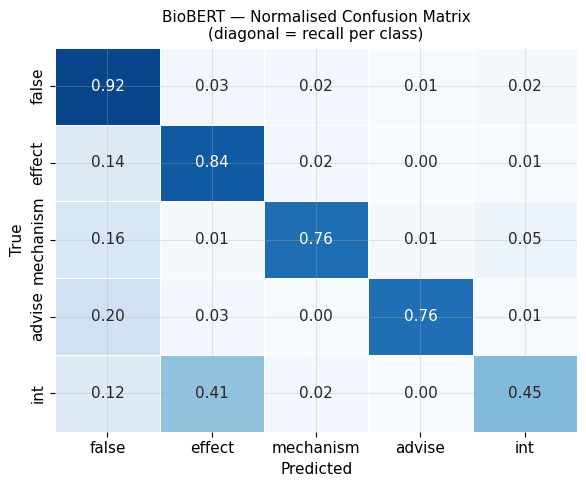

In [8]:
fig, ax = plt.subplots(figsize=(6, 5))

cm  = confusion_matrix(y_true, y_pred)
idx = [CLASS_NAMES.index(l) for l in LABEL_ORDER]

cm_ord = cm[np.ix_(idx, idx)]

row_sums = cm_ord.sum(axis=1, keepdims=True)
row_sums[row_sums == 0] = 1

cm_norm = cm_ord / row_sums

sns.heatmap(
    cm_norm,
    ax=ax,
    annot=True,
    fmt='.2f',
    cmap='Blues',
    xticklabels=LABEL_ORDER,
    yticklabels=LABEL_ORDER,
    vmin=0,
    vmax=1,
    cbar=False,
    linewidths=0.5
)

ax.set_title(
    f'{MODEL_NAME} — Normalised Confusion Matrix\n(diagonal = recall per class)',
    fontsize=11
)

ax.set_xlabel('Predicted')
ax.set_ylabel('True')

plt.tight_layout()

plt.savefig(FIG_DIR / 'confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

## Per-Class F1 Score Analysis

This section presents the F1 score for each interaction class, providing a balanced view of precision and recall.

The dashed line indicates the macro-average F1 score, serving as a reference for overall performance. This visualisation helps compare class-wise performance and identify weaker classes that may require further improvement.

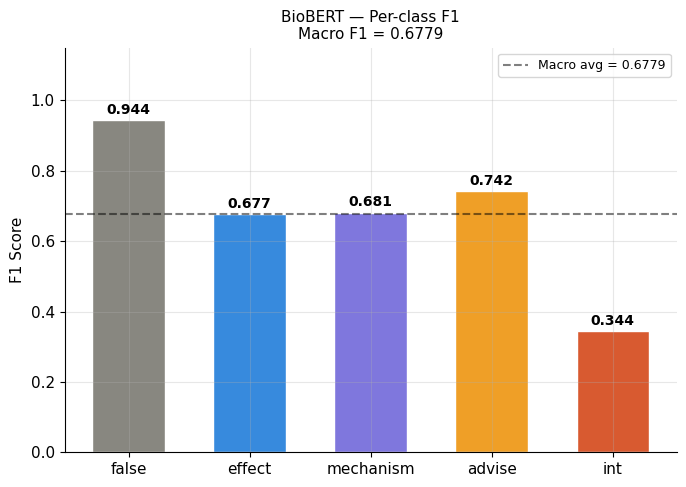

In [9]:
fig, ax = plt.subplots(figsize=(7, 5))

rep = classification_report(
    y_true,
    y_pred,
    target_names=CLASS_NAMES,
    output_dict=True,
    zero_division=0
)

f1_per_class = [rep[lbl]['f1-score'] for lbl in LABEL_ORDER]
cols = [LABEL_COLOURS[l] for l in LABEL_ORDER]

bars = ax.bar(
    LABEL_ORDER,
    f1_per_class,
    color=cols,
    edgecolor='white',
    width=0.6
)

for bar, val in zip(bars, f1_per_class):
    ax.text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height() + 0.01,
        f'{val:.3f}',
        ha='center',
        va='bottom',
        fontsize=10,
        fontweight='bold'
    )

ax.set_title(
    f'{MODEL_NAME} — Per-class F1\nMacro F1 = {summary["macro_f1"]:.4f}',
    fontsize=11
)

ax.set_ylabel('F1 Score')
ax.set_ylim(0, 1.15)

ax.axhline(
    summary['macro_f1'],
    color='black',
    linestyle='--',
    alpha=0.5,
    label=f'Macro avg = {summary["macro_f1"]:.4f}'
)

ax.legend(fontsize=9)

plt.tight_layout()

plt.savefig(FIG_DIR / 'f1_scores.png', dpi=150, bbox_inches='tight')
plt.show()

## Saving Model and Results

This section saves the trained BioBERT model, tokenizer, and evaluation outputs. Predictions and ground truth labels are stored for downstream comparison in later phases.

A results summary is also exported for reporting and benchmarking across models.

In [10]:
# Save Model and Tokeniser
model.save_pretrained(OUTPUT_DIR)
tokeniser.save_pretrained(OUTPUT_DIR)

# Save Predictions
pred_path = BIOBERT_PREDS_NPY
np.save(pred_path, y_pred)


# Save Ground Truth
gt_path = os.path.join(str(MODELS_DIR / 'shared'), 'y_test.npy')
np.save(gt_path, y_true)


# Save Results CSV
res_path = BIOBERT_RESULTS_CSV
pd.DataFrame([summary]).to_csv(res_path, index=False)


# Save Label Mapping
with open(os.path.join(str(MODELS_DIR / 'shared'), 'label2id.json'), 'w') as f:
    json.dump(LABEL2ID, f)


# Final Summary
print(f'{MODEL_NAME} final Macro F1 : {summary["macro_f1"]:.4f}')
print(f'MCC : {summary["mcc"]:.4f}')
print(f'Balanced Accuracy : {summary["bal_acc"]:.4f}')


BioBERT final Macro F1 : 0.6779
MCC : 0.6622
Balanced Accuracy : 0.7441


## Summary

The BioBERT model demonstrates a significant improvement over classical machine learning approaches by effectively capturing contextual and semantic relationships within biomedical text. The use of domain-specific pretraining enables better generalisation, particularly for complex interaction types such as *mechanism* and *effect*.

The application of class-weighted loss mitigates the impact of class imbalance, while early stopping based on Macro F1 ensures stable and efficient training. Evaluation results show that the model achieves strong overall performance, with notable gains in minority class detection compared to earlier phases.

However, certain challenges remain, particularly in distinguishing subtle interaction patterns and handling rare classes such as *int*, which continue to exhibit lower recall. These limitations highlight the importance of further experimentation with alternative transformer architectures.

Overall, this phase establishes BioBERT as a strong baseline for transformer-based DDI classification. The results provide a foundation for comparison with other domain-specific models such as PubMedBERT and SciBERT in subsequent phases.